In [1]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
file_path = '/content/drive/MyDrive/Combined.csv'

# Read the CSV
data = pd.read_csv(file_path)

# Display first few rows
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_8191/4143662039.py:11: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


,Unnamed: 0,Seq,Dur,RunTime,Mean,Sum,Min,Max,Proto,sTos,...,sVid,dVid,SrcTCPBase,DstTCPBase,TcpRtt,SynAck,AckDat,Label,Attack Type,Attack Tool
0,0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,icmp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
1,1,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,icmp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
2,2,3,4.998020,4.998020,4.998020,4.998020,4.998020,4.998020,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
3,3,4,4.998037,4.998037,4.998037,4.998037,4.998037,4.998037,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
4,4,5,4.999453,4.999453,4.999453,4.999453,4.999453,4.999453,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign


In [2]:
!pip install -U tensorflow scikit-learn==1.4.2 scikeras matplotlib seaborn river

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import f_classif, SelectKBest
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Lambda
from scikeras.wrappers import KerasClassifier
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop

# Handle missing values
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())

# Save before encoding
data['Attack_Type_Original'] = data['Attack Type'].astype(str)

# Save a copy of the original Attack Type names before encoding
data['Attack_Type_Original'] = data['Attack Type']
print(data['Attack_Type_Original'].unique())

# Encode categorical columns
ohe_cols = ['Proto', 'State', 'Cause', 'sDSb', 'dDSb']
ohe_cols = [c for c in ohe_cols if c in data.columns]

if ohe_cols:
    data = pd.get_dummies(data, columns=ohe_cols, drop_first=True)

['Benign' 'SYNScan' 'TCPConnectScan' 'UDPScan' 'ICMPFlood' 'UDPFlood'
 'SYNFlood' 'HTTPFlood' 'SlowrateDoS']


In [4]:
if data['Label'].dtype == object:
    data['binary_label'] = data['Label'].apply(
        lambda x: 0 if str(x).strip().lower() in ('Benign','0') else 1
    ).astype(int)
else:
    # numeric: treat 0 as benign, non-zero as attack
    data['binary_label'] = (data['Label'] != 0).astype(int)

#  Filter attack only data
attack_data = data[data['binary_label'] == 1].copy()

In [5]:
# Encode the exact attack type
label_encoder_type = LabelEncoder()
attack_data['Attack_Type_enc'] = label_encoder_type.fit_transform(attack_data['Attack_Type_Original'].astype(str))


In [6]:
print(pd.Series(attack_data['Attack_Type_enc']).value_counts())

Attack_Type_enc
0    477737
7    457340
1    140812
5     73124
6     20052
4     20043
8     15906
3      9721
2      1155
Name: count, dtype: int64


In [7]:
X_type=attack_data.drop(['Label','binary_label','Attack_Type_enc','Attack Type', 'Attack Tool','Unnamed: 0', 'Attack_Type_Original'],axis=1,errors='ignore')
y_type=attack_data['Attack_Type_enc']

# Compute ANOVA F-score
f_scores, p_values = f_classif(X_type, y_type)

# Create a readable table
anova_results = pd.DataFrame({
    "Feature": X_type.columns,
    "F-Score": f_scores,
    "P-Value": p_values
})

anova_results = anova_results.sort_values(by="F-Score", ascending=False)

print("ANOVA selected features:", anova_results)

ANOVA selected features:       Feature       F-Score   P-Value
48  Proto_tcp  2.094398e+06  0.000000
49  Proto_udp  6.665555e+05  0.000000
42     AckDat  3.994659e+05  0.000000
11      sHops  2.275923e+05  0.000000
0         Seq  7.463570e+04  0.000000
..        ...           ...       ...
54  State_NRS  3.862746e-01  0.928570
64    sDSb_54  1.931369e-01  0.991933
76   dDSb_cs4  1.931369e-01  0.991933
36       sVid           NaN       NaN
37       dVid           NaN       NaN

[78 rows x 3 columns]


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [36 37] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [8]:
#Apply ANOVA to Select TOP 10 Features
selector = SelectKBest(score_func=f_classif, k=10)
X_anova = selector.fit_transform(X_type, y_type)

#Get the Names of Selected Features
selected_indices = selector.get_support(indices=True)
top_10_features = X_type.columns[selected_indices]

print(" Top 10 Features from ANOVA:")
print(top_10_features)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [36 37] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


 Top 10 Features from ANOVA:
Index(['Seq', 'sHops', 'Offset', 'dMeanPktSz', 'TcpRtt', 'AckDat', 'Proto_tcp',
       'Proto_udp', 'State_REQ', 'State_RST'],
      dtype='object')


In [9]:
X_type = X_type[top_10_features]

anova_scores = pd.DataFrame({
    "Feature": X_type.columns,
    "F_Score": selector.scores_[selected_indices],
    "p_value": selector.pvalues_[selected_indices]
})

anova_scores = anova_scores.sort_values(by="F_Score", ascending=False)
print(anova_scores.head(10))

      Feature       F_Score  p_value
6   Proto_tcp  2.094398e+06      0.0
7   Proto_udp  6.665555e+05      0.0
5      AckDat  3.994659e+05      0.0
1       sHops  2.275923e+05      0.0
0         Seq  7.463570e+04      0.0
9   State_RST  7.281233e+04      0.0
4      TcpRtt  7.082418e+04      0.0
8   State_REQ  6.351699e+04      0.0
3  dMeanPktSz  5.917655e+04      0.0
2      Offset  5.543114e+04      0.0


In [10]:
#train/test/validate
X_temp_t, X_test_t, y_temp_t, y_test_t = train_test_split(
    X_type, y_type, test_size=0.1, stratify=y_type, random_state=42
)
X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(
    X_temp_t, y_temp_t, test_size=1/9, stratify=y_temp_t, random_state=42
)

In [11]:
# class balance
df_type = pd.concat([X_train_t,y_train_t], axis=1)

target_samples = 30000
balanced_parts = []

for lbl, group in df_type.groupby('Attack_Type_enc'):
    if len(group) > target_samples:
        # Downsample larger classes
        sampled = group.sample(n=target_samples, random_state=42)
    else:
        # Upsample smaller classes
        sampled = resample(group, replace=True, n_samples=target_samples, random_state=42)
    balanced_parts.append(sampled)

df_train_bal = pd.concat(balanced_parts, ignore_index=True)
X_type = df_train_bal.drop('Attack_Type_enc', axis=1)
y_type = df_train_bal['Attack_Type_enc']

# Prepare features/labels
X_train_bal = df_train_bal.drop('Attack_Type_enc', axis=1)
y_train_bal = df_train_bal['Attack_Type_enc']

# Normalize
scaler = StandardScaler()
X_train_bal = scaler.fit_transform(X_train_bal)
X_val_t = scaler.transform(X_val_t)
X_test_t = scaler.transform(X_test_t)


In [12]:
#Build VAE
from tensorflow.keras import layers, Model

input_dim = X_train_bal.shape[1]
latent_dim = 10

encoder_inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(32, activation="relu")(encoder_inputs)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Sampling()([z_mean, z_log_var])

encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(32, activation="relu")(latent_inputs)
decoder_outputs = layers.Dense(input_dim)(x)

decoder = tf.keras.Model(latent_inputs, decoder_outputs, name="decoder")

In [13]:
#VAE loss
class VAE(tf.keras.Model):

    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction), axis=1)
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)

        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

In [14]:
#compile model
vae = VAE(encoder, decoder)

vae.compile(optimizer=tf.keras.optimizers.Adam(), loss="mse")

In [15]:
#Train VAE
vae.fit(
    X_train_bal,
    epochs=30,
    batch_size=128,
    validation_data=(X_val_t, X_val_t),
    verbose=1
)

Epoch 1/30
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - kl_loss: 3.2591 - loss: 6.0815 - reconstruction_loss: 2.8224 - val_loss: 0.3081
Epoch 2/30
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - kl_loss: 2.4970 - loss: 4.3687 - reconstruction_loss: 1.8717 - val_loss: 0.2441
Epoch 3/30
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - kl_loss: 2.9010 - loss: 4.4972 - reconstruction_loss: 1.5963 - val_loss: 0.2003
Epoch 4/30
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - kl_loss: 2.6348 - loss: 3.6636 - reconstruction_loss: 1.0287 - val_loss: 0.1853
Epoch 5/30
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - kl_loss: 2.7630 - loss: 4.5352 - reconstruction_loss: 1.7722 - val_loss: 0.1779
Epoch 6/30
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - kl_loss: 2.4989 - loss: 3.6240 - reconstruction_loss: 1.1251 - val_loss: 0.1730
Epoch 7/30
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - kl_loss: 3.3052 - loss: 4.4319 - reconstruction_loss: 1.1267 - val_loss: 0.1645
Epoch 8/30
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 8s 3m

In [16]:
#Extract latent features
z_mean, _, _ = encoder.predict(X_train_bal)
X_train_latent = z_mean

z_mean, _, _ = encoder.predict(X_val_t)
X_val_latent = z_mean

z_mean, _, _ = encoder.predict(X_test_t)
X_test_latent = z_mean

8438/8438 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [17]:
#Train XGBoost Classifier

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.fit(X_train_latent, y_train_bal)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [18]:
from collections import deque
from river.drift import ADWIN
# Sliding window to store recent prediction probabilities
# This window helps compute adaptive thresholds
prob_window = deque(maxlen=1500)

# Minimum samples before adaptive threshold starts
MIN_SAMPLES_BEFORE_ADAPT = 30


# Initialize ADWIN drift detector
# ADWIN monitors prediction error and detects statistical changes
drift_detector = ADWIN()

# List to store drift detection points
drift_points = []

# Store predicted probabilities for analysis
y_probs_all = []

In [19]:
# Multi-class predictions (no thresholding)
y_pred = xgb_model.predict(X_test_latent)

# Convert to numpy
y_test_np = y_test_t.values

# Store drift-related info
drift_points = []
errors = []

from river.drift import ADWIN
drift_detector = ADWIN()

# Simulate streaming prediction for drift detection
for i in range(len(y_pred)):

    # Current prediction vs actual
    pred = y_pred[i]
    true = y_test_np[i]

    # Compute error (0 = correct, 1 = wrong)
    error = int(pred != true)
    errors.append(error)

    # Update drift detector
    drift_detector.update(error)

    if drift_detector.drift_detected:
        print(f"Drift detected at sample {i}")
        drift_points.append(i)

        # Use recent TEST samples (not training data)
        start = max(0, i - 500)

        X_recent = X_test_latent[start:i]
        y_recent = y_test_np[start:i]

        # Retrain only if enough samples
        if len(X_recent) > 50:
            xgb_model.fit(X_recent, y_recent)


Test Set Results:
Adaptive Accuracy: 0.9936918635731851

[LEVEL 3] Classification Report:
                precision    recall  f1-score   support

        Benign       1.00      0.99      1.00     47774
     HTTPFlood       0.99      0.98      0.98     14081
     ICMPFlood       1.00      1.00      1.00       116
      SYNFlood       0.99      1.00      0.99       972
       SYNScan       1.00      1.00      1.00      2004
   SlowrateDoS       0.95      0.99      0.97      7312
TCPConnectScan       0.99      1.00      0.99      2005
      UDPFlood       1.00      1.00      1.00     45734
       UDPScan       0.97      1.00      0.98      1591

      accuracy                           0.99    121589
     macro avg       0.99      0.99      0.99    121589
  weighted avg       0.99      0.99      0.99    121589



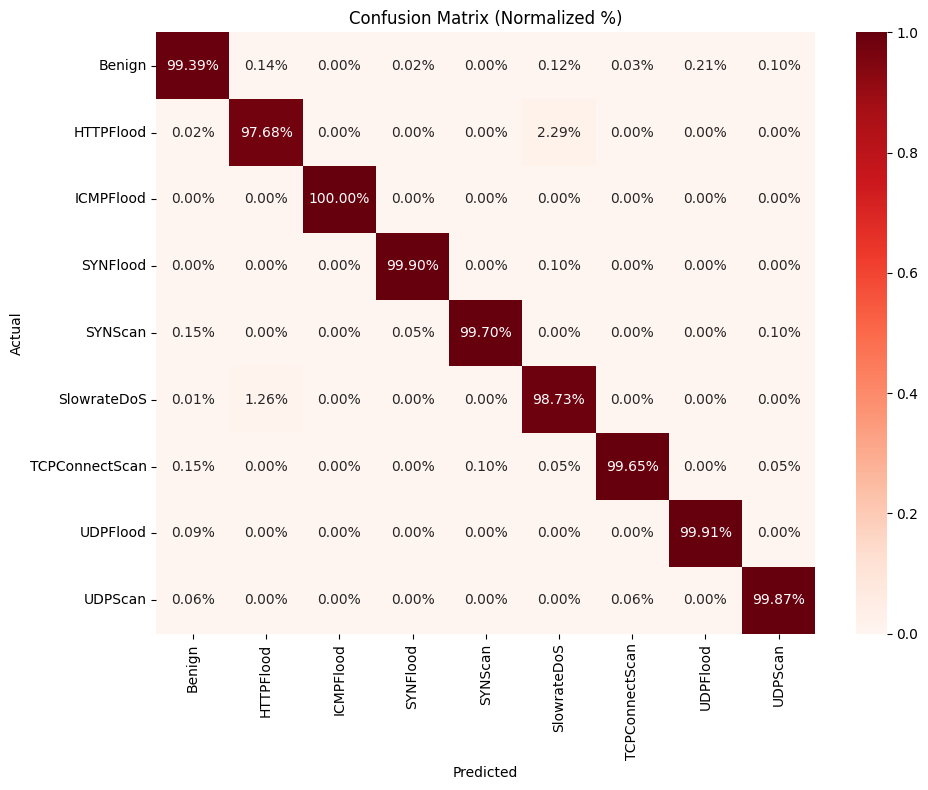

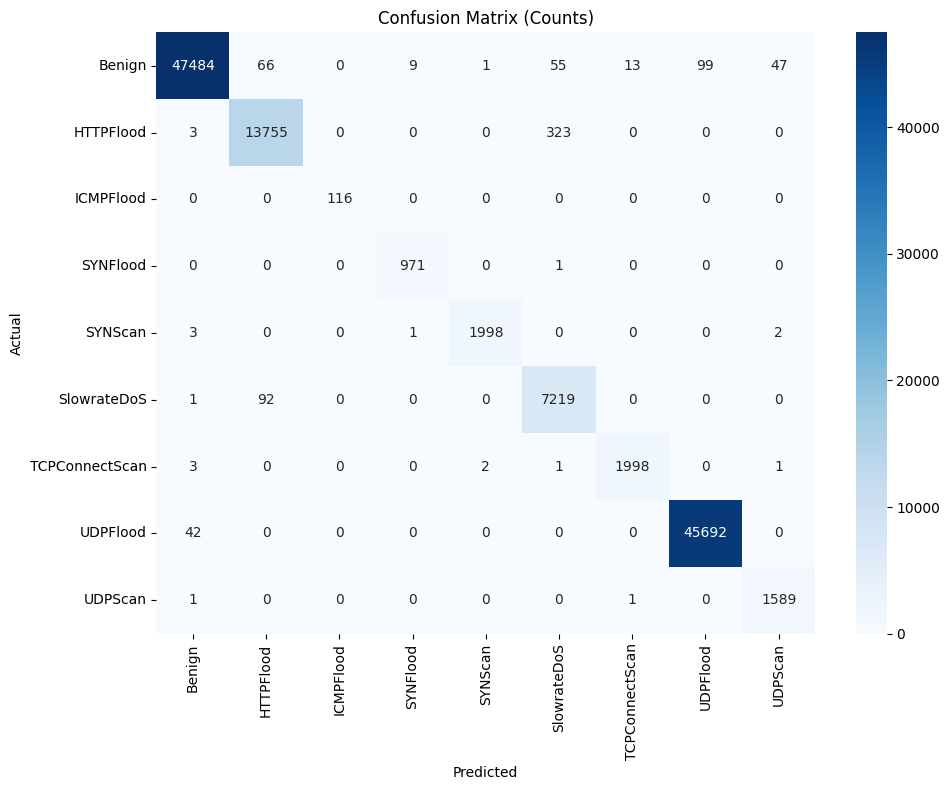

In [20]:
# Decode labels back to original attack names
y_test_labels = label_encoder_type.inverse_transform(y_test_np)
y_pred_labels = label_encoder_type.inverse_transform(y_pred)

print("\nTest Set Results:")
print("Adaptive Accuracy:", accuracy_score(y_test_np, y_pred))

# Classification Report
print("\n[LEVEL 3] Classification Report:")
print(classification_report(
    y_test_np,
    y_pred,
    target_names=label_encoder_type.classes_
))

# Confusion Matrix (use numeric labels for computation)
cm = confusion_matrix(y_test_np, y_pred)

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot normalized confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap='Reds',
            xticklabels=label_encoder_type.classes_,
            yticklabels=label_encoder_type.classes_)
plt.title("Confusion Matrix (Normalized %)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Plot raw confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues',
            xticklabels=label_encoder_type.classes_,
            yticklabels=label_encoder_type.classes_)
plt.title("Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()